11_xgboost_cv_final: XGBoost with Cross Validation

Project root: C:\Users\LENOVO\Desktop\machinelearning_project
Data directory: C:\Users\LENOVO\Desktop\machinelearning_project\data
Model directory: C:\Users\LENOVO\Desktop\machinelearning_project\models\xgb_cv_final

1. Load data...
Train set: (700000, 26)
Test set: (300000, 25)

2. Prepare data...
Original feature count: 24

3. Add engineered features...
Feature count after engineering: 29

4. Encode categorical features...
Encoded feature count: 29
Train feature count: 29
Test feature count: 29

5. Dummy Baseline...
Dummy Classifier AUC: 0.5000 (baseline reference)

6. Start 5-fold cross-validation...

Fold 1/5
Train set: 560000 samples
Validation set: 140000 samples
Validation AUC: 0.725961
Best iteration: 1993
Model saved: C:\Users\LENOVO\Desktop\machinelearning_project\models\xgb_cv_final\xgb_fold_1.json

Fold 2/5
Train set: 560000 samples
Validation set: 140000 samples
Validation AUC: 0.724282
Best iteration: 1997
Model saved: C

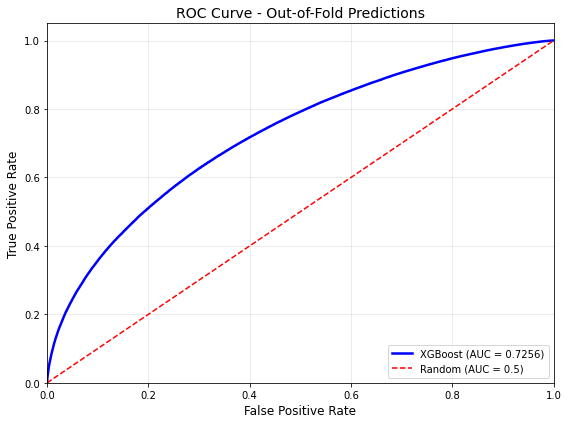

✓ ROC curve saved: C:\Users\LENOVO\Desktop\machinelearning_project\figures\roc_curve.png


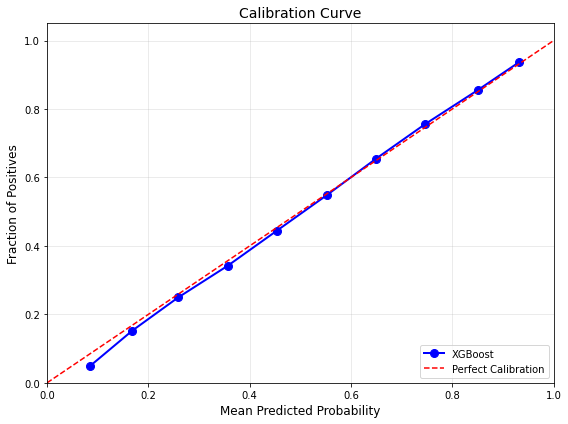

✓ Calibration curve saved: C:\Users\LENOVO\Desktop\machinelearning_project\figures\calibration_curve.png


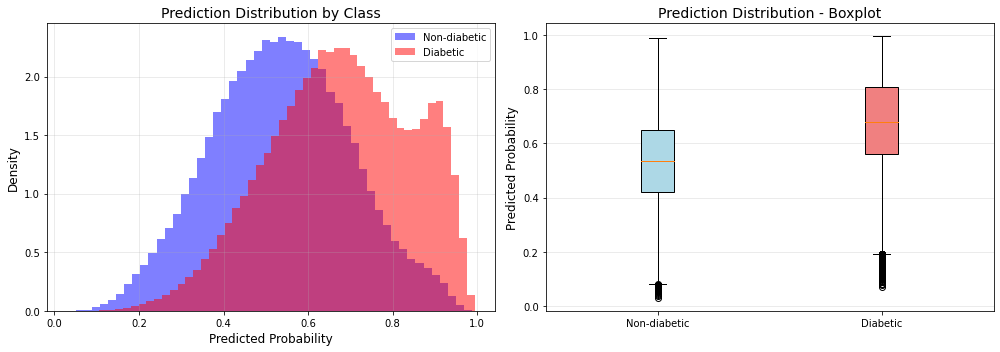

✓ Prediction distribution chart saved: C:\Users\LENOVO\Desktop\machinelearning_project\figures\prediction_distribution.png


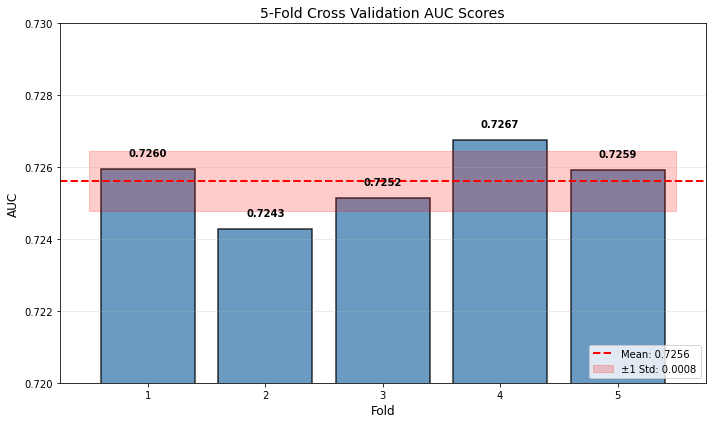

✓ Fold AUC chart saved: C:\Users\LENOVO\Desktop\machinelearning_project\figures\fold_aucs.png

Generate feature importance chart...


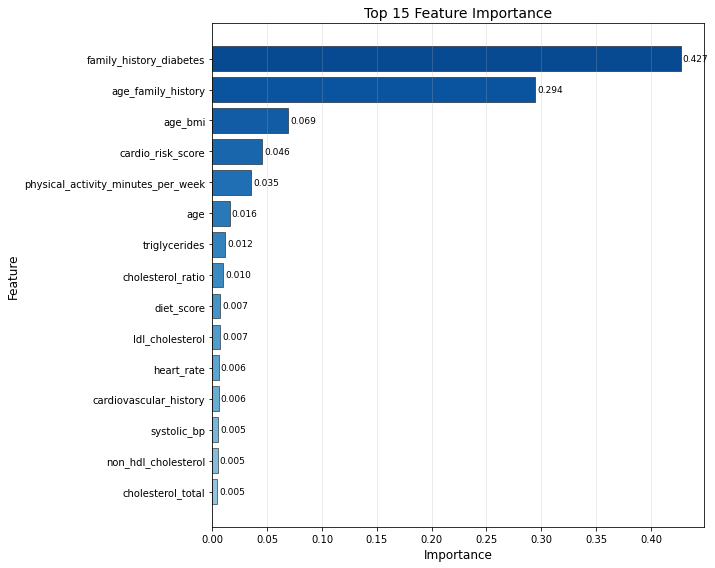

✓ Feature importance chart saved: C:\Users\LENOVO\Desktop\machinelearning_project\figures\feature_importance.png

Generate feature importance pie chart...


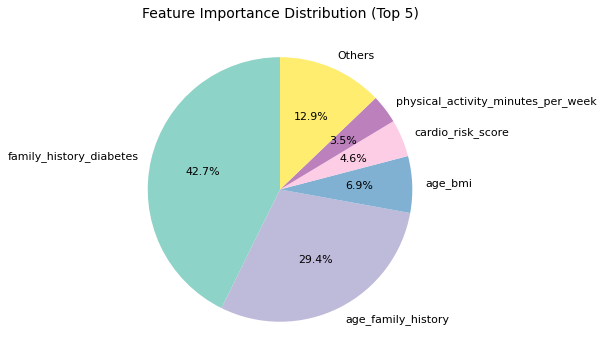

✓ Feature importance pie chart saved: C:\Users\LENOVO\Desktop\machinelearning_project\figures\feature_importance_pie.png

10. Save results...
✓ OOF predictions saved: C:\Users\LENOVO\Desktop\machinelearning_project\logs\11_xgboost_cv_oof_predictions.csv
✓ Feature importance saved: C:\Users\LENOVO\Desktop\machinelearning_project\logs\11_xgboost_cv_feature_importance.csv
✓ Submission file saved: C:\Users\LENOVO\Desktop\machinelearning_project\submissions\11_xgboost_cv_submission.csv

11. Save experiment summary...
✓ Experiment summary saved: C:\Users\LENOVO\Desktop\machinelearning_project\logs\11_xgboost_cv_summary.json

Experiment completed！

Final results: 
- Dummy Baseline AUC: 0.5000
- 5-fold cross-validationMean AUC: 0.725611 (±0.000835) 
- OOF AUC: 0.725604
- Submission file: C:\Users\LENOVO\Desktop\machinelearning_project\submissions\11_xgboost_cv_submission.csv 

Top 5 most important features: 

  22. family_history_diabetes: 0.4271
  25. age_family_history: 0.2945
  26. age_bmi:

In [1]:
# 11_xgboost_cv_final.ipynb

import sys
sys.path.append('..')

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

print("="*60)
print("11_xgboost_cv_final: XGBoost with Cross Validation")
print("="*60)

# Path setup
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == 'notebooks' else CURRENT_DIR

DATA_DIR = PROJECT_ROOT / 'data'
MODEL_DIR = PROJECT_ROOT / 'models/xgb_cv_final'
SUBMISSION_DIR = PROJECT_ROOT / 'submissions'
LOG_DIR = PROJECT_ROOT / 'logs'
FIGURE_DIR = PROJECT_ROOT / 'figures'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'diagnosed_diabetes'
N_SPLITS = 5
RANDOM_STATE = 42

print(f"\nProject root: {PROJECT_ROOT}") 
print(f"Data directory: {DATA_DIR}") 
print(f"Model directory: {MODEL_DIR}") 


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add engineered features while retaining the original predictors.""" 
    df = df.copy()
    
    df['age_family_history'] = df['age'] * df['family_history_diabetes']
    df['age_bmi'] = df['age'] * df['bmi']
    
    df['cardio_risk_score'] = (
        df['family_history_diabetes'] * 3 +
        df['hypertension_history'] * 2 +
        df['cardiovascular_history'] * 2
    )
    
    df['cholesterol_ratio'] = df['cholesterol_total'] / (df['hdl_cholesterol'] + 1)
    df['non_hdl_cholesterol'] = df['cholesterol_total'] - df['hdl_cholesterol']
    
    return df


def encode_categorical(df: pd.DataFrame) -> pd.DataFrame:
    """Label encoding for categorical features"""
    df = df.copy()
    categorical_cols = ['gender', 'ethnicity', 'education_level', 
                        'income_level', 'smoking_status', 'employment_status']
    
    for col in categorical_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = df[col].fillna('Unknown')
            df[col] = le.fit_transform(df[col].astype(str))
    
    return df


def build_model(seed: int = RANDOM_STATE) -> XGBClassifier:
    """Build the XGBoost model with the optimized parameters used in this stage.""" 
    return XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1,
        reg_alpha=0.1,
        reg_lambda=1,
        random_state=seed,
        n_jobs=-1,
        early_stopping_rounds=100,
        verbosity=0
    )


def plot_roc_curve(y_true, y_pred, title=None, save_path=None):
    """Plot the ROC curve.""" 
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc_score:.4f}')
    plt.plot([0, 1], [0, 1], 'r--', label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title or 'ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_calibration_curve(y_true, y_pred, title=None, save_path=None):
    """Plot the calibration curve.""" 
    prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=10)
    
    plt.figure(figsize=(6, 5))
    plt.plot(prob_pred, prob_true, 'o-', linewidth=2, label='XGBoost')
    plt.plot([0, 1], [0, 1], 'r--', label='Perfect Calibration')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title(title or 'Calibration Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_prediction_distribution(y_true, y_pred, title=None, save_path=None):
    """Plot the predicted-probability distribution by class.""" 
    plt.figure(figsize=(8, 5))
    plt.hist(y_pred[y_true == 0], bins=50, alpha=0.5, label='Non-diabetic', color='blue')
    plt.hist(y_pred[y_true == 1], bins=50, alpha=0.5, label='Diabetic', color='red')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Frequency')
    plt.title(title or 'Prediction Distribution by Class')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def main():
    # 1. Load data
    print("\n1. Load data...") 
    train_df = pd.read_csv(DATA_DIR / 'train.csv')
    test_df = pd.read_csv(DATA_DIR / 'test.csv')
    sample_sub = pd.read_csv(DATA_DIR / 'sample_submission.csv')
    
    print(f"Train set: {train_df.shape}") 
    print(f"Test set: {test_df.shape}") 
    
    id_col = sample_sub.columns[0]
    pred_col = sample_sub.columns[1]
    
    # 2. Prepare data
    print("\n2. Prepare data...") 
    X = train_df.drop(columns=[id_col, TARGET])
    y = train_df[TARGET].astype(int)
    X_test = test_df.drop(columns=[id_col])
    
    print(f"Original feature count: {X.shape[1]}") 
    
    # 3. Add engineered features
    print("\n3. Add engineered features...") 
    X = add_engineered_features(X)
    X_test = add_engineered_features(X_test)
    print(f"Feature count after engineering: {X.shape[1]}") 
    
    # 4. Encode categorical features
    print("\n4. Encode categorical features...") 
    X = encode_categorical(X)
    X_test = encode_categorical(X_test)
    print(f"Encoded feature count: {X.shape[1]}") 
    
    missing_cols = set(X.columns) - set(X_test.columns)
    for col in missing_cols:
        X_test[col] = 0
    X_test = X_test[X.columns]
    
    print(f"Train feature count: {X.shape[1]}") 
    print(f"Test feature count: {X_test.shape[1]}") 
    
    # 5. Dummy baseline
    print("\n5. Dummy Baseline...")
    X_sample, X_val_sample, y_sample, y_val_sample = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    
    dummy = DummyClassifier(strategy='most_frequent')
    dummy.fit(X_sample, y_sample)
    dummy_pred = dummy.predict_proba(X_val_sample)[:, 1]
    dummy_auc = roc_auc_score(y_val_sample, dummy_pred)
    print(f"Dummy Classifier AUC: {dummy_auc:.4f} (baseline reference)")
    
    # 6. 5-fold cross-validation
    print("\n6. Start 5-fold cross-validation...") 
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    
    oof_pred = np.zeros(len(X), dtype=float)
    test_pred = np.zeros(len(X_test), dtype=float)
    fold_scores = []
    best_iterations = []
    feature_importance_sum = np.zeros(X.shape[1])
    
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        print(f"\n{'='*40}")
        print(f"Fold {fold}/{N_SPLITS}")
        print(f"{'='*40}")
        
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        
        print(f"Train set: {len(X_train)} samples") 
        print(f"Validation set: {len(X_valid)} samples") 
        
        model = build_model(seed=RANDOM_STATE + fold)
        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False
        )
        
        valid_pred = model.predict_proba(X_valid)[:, 1]
        fold_auc = roc_auc_score(y_valid, valid_pred)
        oof_pred[valid_idx] = valid_pred
        fold_scores.append(fold_auc)
        
        best_iter = model.best_iteration if hasattr(model, 'best_iteration') else None
        best_iterations.append(best_iter)
        
        print(f"Validation AUC: {fold_auc:.6f}") 
        if best_iter:
            print(f"Best iteration: {best_iter}") 
        
        feature_importance_sum += model.feature_importances_
        
        test_pred += model.predict_proba(X_test)[:, 1] / N_SPLITS
        
        model.save_model(MODEL_DIR / f'xgb_fold_{fold}.json')
        print(f"Model saved: {MODEL_DIR / f'xgb_fold_{fold}.json'}") 
    
        # 7. Compute final results
    print("\n" + "="*60)
    print("Cross-validation summary") 
    print("="*60)
    
    oof_auc = roc_auc_score(y, oof_pred)
    mean_fold_auc = np.mean(fold_scores)
    std_fold_auc = np.std(fold_scores)
    
    print(f"\nFold AUCs: {[round(s, 6) for s in fold_scores]}") 
    print(f"Mean AUC: {mean_fold_auc:.6f}") 
    print(f"Std: {std_fold_auc:.6f}") 
    print(f"OOF AUC: {oof_auc:.6f}")
    
    # 8. Feature importance
    print("\n8. Feature importance analysis...") 
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': feature_importance_sum / N_SPLITS
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10 most important features:") 
    print(feature_importance.head(10).to_string(index=False))
    
    # Replace the figure section(starting from Part 9)

    # 9. Visualization analysis(refined version)
    print("\n9. Generate visualization analysis...") 

    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['legend.fontsize'] = 10

    # Figure 1: ROC curve(clearer version)
    fig, ax = plt.subplots(figsize=(8, 6))
    fpr, tpr, _ = roc_curve(y, oof_pred)
    auc_score = roc_auc_score(y, oof_pred)

    ax.plot(fpr, tpr, 'b-', linewidth=2.5, label=f'XGBoost (AUC = {auc_score:.4f})')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random (AUC = 0.5)')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curve - Out-of-Fold Predictions', fontsize=14)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ ROC curve saved: {FIGURE_DIR / 'roc_curve.png'}") 

    # Figure2: Calibration curve(refined version)
    fig, ax = plt.subplots(figsize=(8, 6))
    prob_true, prob_pred = calibration_curve(y, oof_pred, n_bins=10, strategy='uniform')

    ax.plot(prob_pred, prob_true, 'o-', color='blue', linewidth=2, markersize=8, label='XGBoost')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect Calibration')
    ax.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax.set_ylabel('Fraction of Positives', fontsize=12)
    ax.set_title('Calibration Curve', fontsize=14)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'calibration_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Calibration curve saved: {FIGURE_DIR / 'calibration_curve.png'}") 

    # Figure 3: Prediction probability distribution(refined version, shown separately)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: density plot(clearer view)
    ax1 = axes[0]
    # Use a density plot instead of a histogram to avoid overlap
    for label, color, name in [(0, 'blue', 'Non-diabetic'), (1, 'red', 'Diabetic')]:
        mask = y == label
        ax1.hist(oof_pred[mask], bins=50, alpha=0.5, density=True, 
                color=color, label=name, edgecolor='none')
    ax1.set_xlabel('Predicted Probability', fontsize=12)
    ax1.set_ylabel('Density', fontsize=12)
    ax1.set_title('Prediction Distribution by Class', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Right: separate boxplots(showing differences more clearly)
    ax2 = axes[1]
    data_to_plot = [oof_pred[y == 0], oof_pred[y == 1]]
    bp = ax2.boxplot(data_to_plot, labels=['Non-diabetic', 'Diabetic'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    ax2.set_ylabel('Predicted Probability', fontsize=12)
    ax2.set_title('Prediction Distribution - Boxplot', fontsize=14)
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'prediction_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Prediction distribution chart saved: {FIGURE_DIR / 'prediction_distribution.png'}") 

    # Figure4: FoldAUCbar chart(refined version)
    fig, ax = plt.subplots(figsize=(10, 6))

    # bar chart
    bars = ax.bar(range(1, N_SPLITS + 1), fold_scores, color='steelblue', 
                edgecolor='black', linewidth=1.5, alpha=0.8)

    for bar, score in zip(bars, fold_scores):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.0003,
                f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.axhline(y=mean_fold_auc, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_fold_auc:.4f}')

    ax.fill_between([0.5, 5.5], [mean_fold_auc - std_fold_auc, mean_fold_auc - std_fold_auc],
                    [mean_fold_auc + std_fold_auc, mean_fold_auc + std_fold_auc],
                    alpha=0.2, color='red', label=f'±1 Std: {std_fold_auc:.4f}')

    ax.set_xlabel('Fold', fontsize=12)
    ax.set_ylabel('AUC', fontsize=12)
    ax.set_title('5-Fold Cross Validation AUC Scores', fontsize=14)
    ax.set_xticks(range(1, N_SPLITS + 1))
    ax.set_ylim(0.72, 0.73)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'fold_aucs.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Fold AUC chart saved: {FIGURE_DIR / 'fold_aucs.png'}") 

    # Figure5: Feature importancebar chart(refined version)
    print("\nGenerate feature importance chart...") 
    fig, ax = plt.subplots(figsize=(10, 8))

    top_n = 15
    top_features = feature_importance.head(top_n)

    # Horizontal bar chart
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))
    bars = ax.barh(range(len(top_features)), top_features['importance'], 
                color=colors[::-1], edgecolor='black', linewidth=0.5)

    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'], fontsize=10)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    ax.set_title(f'Top {top_n} Feature Importance', fontsize=14)
    ax.invert_yaxis()

    for i, (idx, row) in enumerate(top_features.iterrows()):
        ax.text(row['importance'] + 0.002, i, f'{row["importance"]:.3f}', 
                va='center', fontsize=9)

    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Feature importance chart saved: {FIGURE_DIR / 'feature_importance.png'}") 

    # Figure6: Feature importancepie chart(Top 5)
    print("\nGenerate feature importance pie chart...") 
    fig, ax = plt.subplots(figsize=(8, 8))

    top_n_pie = 5
    top_pie = feature_importance.head(top_n_pie)
    others_sum = feature_importance.iloc[top_n_pie:]['importance'].sum()

    pie_data = list(top_pie['importance']) + [others_sum]
    pie_labels = list(top_pie['feature']) + ['Others']

    colors = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
    wedges, texts, autotexts = ax.pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
                                        colors=colors, startangle=90,
                                        textprops={'fontsize': 11})
    ax.set_title(f'Feature Importance Distribution (Top {top_n_pie})', fontsize=14)

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'feature_importance_pie.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Feature importance pie chart saved: {FIGURE_DIR / 'feature_importance_pie.png'}") 
        
    # 10. Save results
    print("\n10. Save results...") 
    
    oof_df = pd.DataFrame({
        id_col: train_df[id_col],
        'y_true': y,
        'oof_pred': oof_pred
    })
    oof_df.to_csv(LOG_DIR / '11_xgboost_cv_oof_predictions.csv', index=False)
    print(f"✓ OOF predictions saved: {LOG_DIR / '11_xgboost_cv_oof_predictions.csv'}") 
    
    feature_importance.to_csv(LOG_DIR / '11_xgboost_cv_feature_importance.csv', index=False)
    print(f"✓ Feature importance saved: {LOG_DIR / '11_xgboost_cv_feature_importance.csv'}") 
    
    submission = sample_sub.copy()
    submission[pred_col] = test_pred
    submission.to_csv(SUBMISSION_DIR / '11_xgboost_cv_submission.csv', index=False)
    print(f"✓ Submission file saved: {SUBMISSION_DIR / '11_xgboost_cv_submission.csv'}") 
    
    # 11. Save experiment summary
    print("\n11. Save experiment summary...") 
    
    summary = {
        'experiment': '11_xgboost_cv_final',
        'n_splits': N_SPLITS,
        'random_state': RANDOM_STATE,
        'dummy_baseline_auc': dummy_auc,
        'fold_aucs': fold_scores,
        'mean_fold_auc': float(mean_fold_auc),
        'std_fold_auc': float(std_fold_auc),
        'oof_auc': float(oof_auc),
        'best_iterations': best_iterations,
        'feature_count': X.shape[1],
        'top_features': feature_importance.head(10).to_dict('records'),
        'params': {
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'tree_method': 'hist',
            'n_estimators': 2000,
            'learning_rate': 0.03,
            'max_depth': 4,
            'min_child_weight': 5,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'gamma': 1,
            'reg_alpha': 0.1,
            'reg_lambda': 1,
            'early_stopping_rounds': 100
        }
    }
    
    with open(LOG_DIR / '11_xgboost_cv_summary.json', 'w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)
        print(f"✓ Experiment summary saved: {LOG_DIR / '11_xgboost_cv_summary.json'}") 
    
        # 12. Print final summary
    print("\n" + "="*60)
    print("Experiment completed！") 
    print("="*60)
    print(f"""
Final results: 
- Dummy Baseline AUC: {dummy_auc:.4f}
- 5-fold cross-validationMean AUC: {mean_fold_auc:.6f} (±{std_fold_auc:.6f}) 
- OOF AUC: {oof_auc:.6f}
- Submission file: {SUBMISSION_DIR / '11_xgboost_cv_submission.csv'} 

Top 5 most important features: 
""")
    for i, row in feature_importance.head(5).iterrows():
        print(f"  {i+1}. {row['feature']}: {row['importance']:.4f}")


if __name__ == "__main__":
    main()


# Experiment 11: XGBoost Cross-Validation Workflow

This notebook introduces the main notebook-stage XGBoost cross-validation workflow. Its role is different from the earlier exploratory experiment notebooks: instead of testing a single local idea, it consolidates the strongest modeling choices into a more reliable validation framework.

## Purpose

The notebook focuses on three goals:

- use 5-fold stratified cross-validation for a more stable performance estimate at this stage of the project
- apply fold-aware preprocessing and evaluation logic to reduce leakage risk
- produce training artifacts, predictions, and report-ready figures in a more reproducible way

## Scope

This notebook should be interpreted as the project's main notebook-stage training workflow before the later supporting notebooks broaden the discussion of validation design. Earlier notebooks remain useful as experimental records, but this notebook marks the shift from exploratory holdout tuning toward a more defensible evaluation setup.

## Reading Guide

When reviewing the outputs, the most important quantities are:

- fold-level AUC values
- mean and standard deviation across folds
- out-of-fold AUC
- feature importance and diagnostic plots

A practical interpretation is that this notebook emphasizes robustness and reproducibility rather than isolated single-split gains.
